# Week 1 - First Notebook and First SQL Query

Welcome to BIA 5476. This is the first notebook, so the goal is to become comfortable with the notebook format before focusing on the SQL details.

A notebook is made of cells. Text cells use Markdown for explanations. Code cells can run Python, and cells that begin with `%%sql` run SQL. Run cells from top to bottom with `Shift` + `Enter`.

## Cell 1 - Markdown Text

This is a Markdown cell. Markdown cells are for notes, explanations, titles, links, and instructions. They do not query the database.

This is an example of plain text in a notebook.

You can also add emphasis, for example: **different format**

## Cell 2 - Python Setup

This is a Python cell. It imports a small utility used in the next cell. The setup reminder is a comment, so Python ignores it when the cell runs.

In [9]:
from time import ctime
# Local setup: install packages once from the terminal with `python -m pip install -r requirements.txt`.


## Cell 3 - Check That the Kernel Is Running

This Python cell prints the current time from your computer. If this runs, the notebook kernel is working.

In [10]:
print(f"Today is {ctime()}")

Today is Sat May 16 09:42:54 2026


## Cell 4 - Connect to the Local SQLite Database

This setup cell finds the project folder on your computer, builds the path to `zagimore.db`, loads the SQL notebook extension, and connects to the database. Run this before running any `%%sql` cells.

In [11]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    (PROJECT_ROOT / "README.md").exists()
    and (PROJECT_ROOT / "requirements.txt").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "requirements.txt").exists():
    raise FileNotFoundError(
        "Could not find the project root. Start Jupyter from the DataManagement-BusinessIntelligence folder."
    )

db_path = (PROJECT_ROOT / "zagimore.db").resolve().as_posix()
connection_string = f"sqlite:///{db_path}"

%reload_ext sql
%sql $connection_string


## Cell 5 - First SQL Cell: List the Tables

The first line, `%%sql`, tells Jupyter that the rest of the cell is SQL. This query asks SQLite to show the names of all tables in the connected database.

In [12]:
%%sql

SELECT name FROM sqlite_master WHERE type='table';

 * sqlite:////Users/vanessadamario/src/DataManagement-BusinessIntelligence/zagimore.db
Done.


name
vendor
category
product
region
store
customer
salestransaction
soldvia


## Cell 6 - Query the Product Table

This SQL query retrieves all columns and all rows from the `product` table. This is the first example of using SQL to inspect a real table.

In [13]:
%%sql

select * from product;

 * sqlite:////Users/vanessadamario/src/DataManagement-BusinessIntelligence/zagimore.db
Done.


productid,productname,productprice,vendorid,categoryid
1X1,Zzz Bag,100,PG,CP
2X2,Easy Boot,70,MK,FW
3X3,Cosy Sock,15,MK,FW
4X4,Dura Boot,90,PG,FW
5X5,Tiny Tent,150,MK,CP
6X6,Biggy Tent,250,MK,CP
7X7,Hi-Tec GPS,300,OA,EL
8X8,Power Pedals,20,MK,CY
9X9,Trusty Rope,30,WL,CL
1X2,Comfy Harness,150,MK,CL


## Cell 7 - Store SQL Results for Python

This cell runs a SQL query and stores the result in a Python variable named `result`. Then it converts the result into a pandas DataFrame named `df`, which Python can display and plot.

In [14]:
result = %sql SELECT * FROM product;
df = result.DataFrame()

 * sqlite:////Users/vanessadamario/src/DataManagement-BusinessIntelligence/zagimore.db
Done.


## Cell 8 - Display the DataFrame

Typing the name of a Python variable at the end of a cell displays its contents. Here, `df` shows the SQL result as a table inside the notebook.

In [15]:
df

,productid,productname,productprice,vendorid,categoryid
0,1X1,Zzz Bag,100,PG,CP
1,2X2,Easy Boot,70,MK,FW
2,3X3,Cosy Sock,15,MK,FW
3,4X4,Dura Boot,90,PG,FW
4,5X5,Tiny Tent,150,MK,CP
5,6X6,Biggy Tent,250,MK,CP
6,7X7,Hi-Tec GPS,300,OA,EL
7,8X8,Power Pedals,20,MK,CY
8,9X9,Trusty Rope,30,WL,CL
9,1X2,Comfy Harness,150,MK,CL


## Cell 9 - Make a Simple Chart

This is Python again. It groups the data by `vendorid` and creates a small bar chart. SQL is used to retrieve the data; Python is used here to visualize it.

The following plot answer the question: **Given the sold products which are recorded - How many vendors do we have and how many different products do they sell?**

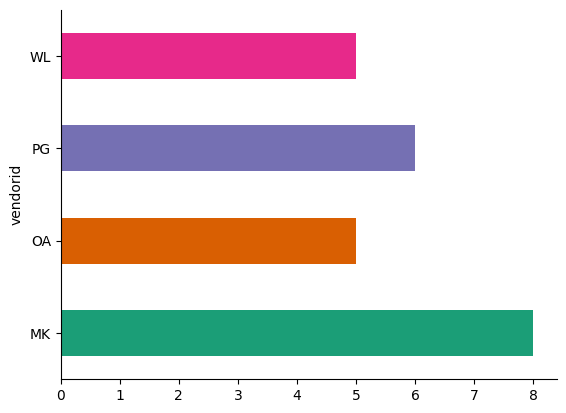

In [16]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('vendorid').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

## Cell 10 - Practice Space

This empty code cell is available for practice. You can try another Python command here, or leave it blank.

## Cell 11 - More Practice Space

This second empty code cell is another place to experiment without changing the examples above.